In [1]:
from prompt_toolkit import keys
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
from Utils.json_tools import read_formatted_json
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter1d
from plotting import plot_1d_rfmap

In [2]:
base_dir: Path = Path("/Volumes/senzailab/Kai/#Recording/m15/")
date = 260630

sessionID = 3
probe: str = "A"

session_dir = base_dir / str(date)
hd_session = session_dir / f"{date}_1"
rf_session = session_dir / f"{date}_{sessionID}"

In [22]:
rf_json_path = rf_session / f"data/rfmapping/good/0_200_1ms/Probe{probe}/regular_unitsSpikeCounts_{date}_{sessionID}.json"

rf_data = read_formatted_json(rf_json_path)
assert rf_data["unitsSpikeCountsSize"][3] == (len(rf_data['timeBinEdges']) - 1) == len(
    rf_data['unitsSpikeCounts'][0][0][0])
RFunitsSpikeCounts_time = np.asarray(rf_data['unitsSpikeCounts'])
RFunitPool = np.asarray(rf_data['unitPool'])

RFunitsSpikeCounts1D = RFunitsSpikeCounts_time.sum(axis=(1, 3))

In [24]:
RFunitsSpikeCounts2D = RFunitsSpikeCounts_time.sum(axis=(3))


In [31]:
RFunitsSpikeCounts2D[0][0][0]

np.int64(125)

In [4]:
hd_json_path = hd_session / f"data/tuning_curves/Probe{probe}/tuning_curves.json"
hd_data = read_formatted_json(hd_json_path)

HDunitPool = np.asarray(hd_data['unit_id'])
HDunitSpikeCounts = np.asarray(hd_data['spike_counts'])

assert len(HDunitPool) == len(HDunitSpikeCounts)

In [18]:
targetList = [
    108, 114, 124, 127, 131, 133, 134, 137, 139, 141, 153, 156, 160, 267, 270, 274, 275, 279, 280, 285, 287, 291, 294,
    296, 307, 318, 423, 459,
]

HDselectionMask = np.isin(HDunitPool, targetList)
HDselectedSpikeCounts = HDunitSpikeCounts[HDselectionMask, :].astype(float)
HDselectedUnitIDs = HDunitPool[HDselectionMask]

HDoccupancyTime180 = np.asarray(hd_data['occupancy_time_s'], dtype=float)
HDangleBinEdges180 = np.asarray(hd_data['angle_bin_edges_deg'], dtype=float)

HD_BIN_COUNT = 30
HD_BINS_PER_GROUP = HDselectedSpikeCounts.shape[1] // HD_BIN_COUNT
assert HDselectedSpikeCounts.shape[1] == 180
assert HD_BINS_PER_GROUP == 6
assert HDoccupancyTime180.shape == (180,)
assert HDangleBinEdges180.shape == (181,)

# Sum six adjacent 2-degree bins before applying the occupancy correction.
HDselectedSpikeCounts30 = HDselectedSpikeCounts.reshape(
    len(HDselectedUnitIDs), HD_BIN_COUNT, HD_BINS_PER_GROUP
).sum(axis=2)
HDoccupancyTime30 = HDoccupancyTime180.reshape(
    HD_BIN_COUNT, HD_BINS_PER_GROUP
).sum(axis=1)
HDangleBinEdges30 = HDangleBinEdges180[::HD_BINS_PER_GROUP]

HDunitsFiringRates30 = np.divide(
    HDselectedSpikeCounts30,
    HDoccupancyTime30[None, :],
    out=np.full(HDselectedSpikeCounts30.shape, np.nan),
    where=HDoccupancyTime30[None, :] > 0,
)

# Preserve the original 3-degree smoothing width: 1.5 old bins = 0.25 new bins.
HD_SMOOTH_SIGMA_30 = 0.25
HDselectedSpikeCounts30_smooth = gaussian_filter1d(
    HDselectedSpikeCounts30,
    sigma=HD_SMOOTH_SIGMA_30,
    axis=1,
    mode='wrap',
)
HDoccupancyTime30_smooth = gaussian_filter1d(
    HDoccupancyTime30,
    sigma=HD_SMOOTH_SIGMA_30,
    mode='wrap',
)
HDunitsFiringRates30_smooth = np.divide(
    HDselectedSpikeCounts30_smooth,
    HDoccupancyTime30_smooth[None, :],
    out=np.full(HDselectedSpikeCounts30.shape, np.nan),
    where=HDoccupancyTime30_smooth[None, :] > 0,
)

HDrank_idx = np.argsort(HDmaxIndex := np.nanargmax(HDunitsFiringRates30_smooth, axis=1))
HDunitsFiringRates30_smooth_sorted = HDunitsFiringRates30_smooth[HDrank_idx, :]
HDtargetList_sorted = HDselectedUnitIDs[HDrank_idx]

In [7]:
def normalized_shannon_entropy_per_row(arr):
    arr = np.asarray(arr, dtype=float)

    # row-wise sum: shape (n_rows, 1)

    row_sum = arr.sum(axis=1, keepdims=True)

    # avoid divide-by-zero for all-zero rows

    p = np.divide(arr, row_sum, out=np.zeros_like(arr), where=row_sum != 0)

    # entropy per row

    H = -np.sum(

        np.where(p > 0, p * np.log2(p), 0),

        axis=1

    )

    # max entropy per row = log2(number of columns)

    H_max = np.log2(arr.shape[1])

    return H / H_max

In [8]:
targetList = [
    108, 114, 124, 127, 131, 133, 134, 137, 139, 141, 153, 156, 160, 267, 270, 274, 275, 279, 280, 285, 287, 291, 294,
    296, 307, 318, 423, 459,
]


RFselectedSpikeCounts = RFunitsSpikeCounts[np.isin(RFunitPool, targetList), :]

RFselectedUnitIDs = np.array(targetList)

RFunitsSpikeCounts_smooth = gaussian_filter1d(
    RFselectedSpikeCounts,
    sigma=1.5,
    axis=1
)

RFrank_idx = np.argsort(RFmaxIndex := np.argmax(RFunitsSpikeCounts_smooth, axis=1))
# rank_idx = np.asarray([ 2,  8, 15, 21, 24, 27, 10,  7, 25, 12,  3, 20, 16, 17,  4,  1, 26,
#        19,  0, 22,  6,  5, 11, 13,  9, 23, 14, 18])
RFunitsSpikeCounts_smooth_sorted = RFunitsSpikeCounts_smooth[RFrank_idx, :]
RFtargetList_sorted = RFselectedUnitIDs[RFrank_idx]

In [15]:
# Shared controls and statistics for both circular scatter plots.
import numpy as np
from scipy.stats import circmean, rankdata

SHOW_STATS_ON_PLOT = True
SHOW_PAIR_LABELS = False
N_PERMUTATIONS = 10_000
PERMUTATION_SEED = 1


def format_permutation_p(p_value):
    if not np.isfinite(p_value):
        return 'nan'
    return f'{p_value:.5f}' if p_value < 0.001 else f'{p_value:.4f}'


def style_white_scatter_axes(fig, ax):
    fig.patch.set_facecolor('white')
    fig.patch.set_alpha(1.0)
    ax.set_facecolor('white')
    ax.tick_params(colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')
    for spine in ax.spines.values():
        spine.set_color('black')
    ax.grid(color='0.85', linewidth=0.8)


def circ_corrcc(alpha, beta):
    """Jammalamadaka-SenGupta circular-circular correlation."""
    alpha = np.asarray(alpha, dtype=float).ravel()
    beta = np.asarray(beta, dtype=float).ravel()
    if alpha.shape != beta.shape:
        raise ValueError('alpha and beta must have the same shape')

    mask = np.isfinite(alpha) & np.isfinite(beta)
    alpha = alpha[mask]
    beta = beta[mask]
    if alpha.size < 3:
        raise ValueError('At least three finite angle pairs are required')
    if min(
        np.abs(np.mean(np.exp(1j * alpha))),
        np.abs(np.mean(np.exp(1j * beta))),
    ) <= np.finfo(float).eps:
        return np.nan

    alpha_bar = circmean(alpha, high=2 * np.pi, low=0)
    beta_bar = circmean(beta, high=2 * np.pi, low=0)
    sin_alpha = np.sin(alpha - alpha_bar)
    sin_beta = np.sin(beta - beta_bar)
    denominator = np.sqrt(
        np.sum(sin_alpha ** 2) * np.sum(sin_beta ** 2)
    )
    if np.isclose(denominator, 0):
        return np.nan
    return np.sum(sin_alpha * sin_beta) / denominator


def circ_corrcc_permtest(alpha, beta, n_perm=10_000, seed=0):
    """Two-sided circular-circular unit-label permutation test."""
    if n_perm < 1:
        raise ValueError('n_perm must be positive')
    alpha = np.asarray(alpha, dtype=float).ravel()
    beta = np.asarray(beta, dtype=float).ravel()
    if alpha.shape != beta.shape:
        raise ValueError('alpha and beta must have the same shape')

    mask = np.isfinite(alpha) & np.isfinite(beta)
    alpha = alpha[mask]
    beta = beta[mask]
    if alpha.size < 3:
        raise ValueError('At least three finite angle pairs are required')

    rho_obs = circ_corrcc(alpha, beta)
    if not np.isfinite(rho_obs):
        return rho_obs, np.nan

    rng = np.random.default_rng(seed)
    perm_rhos = np.empty(n_perm)
    for i in range(n_perm):
        perm_rhos[i] = circ_corrcc(alpha, rng.permutation(beta))

    p_value = (
        np.sum(np.abs(perm_rhos) >= np.abs(rho_obs)) + 1
    ) / (n_perm + 1)
    return rho_obs, p_value


def circular_distance_matrix_deg(angles_deg):
    """Pairwise shortest-arc distances, in degrees (range 0-180)."""
    angles_deg = np.asarray(angles_deg, dtype=float).ravel()
    if not np.all(np.isfinite(angles_deg)):
        raise ValueError('All angles must be finite')
    delta = angles_deg[:, None] - angles_deg[None, :]
    return np.abs((delta + 180.0) % 360.0 - 180.0)


def spearman_mantel_permtest(HDangles_deg, RFangles_deg, n_perm=10_000, seed=0):
    """Spearman Mantel test with simultaneous RF row/column permutations."""
    HDangles_deg = np.asarray(HDangles_deg, dtype=float).ravel()
    RFangles_deg = np.asarray(RFangles_deg, dtype=float).ravel()
    if n_perm < 1:
        raise ValueError('n_perm must be positive')
    if HDangles_deg.shape != RFangles_deg.shape:
        raise ValueError('HD and RF angles must have the same shape')
    if HDangles_deg.size < 3:
        raise ValueError('At least three paired units are required')

    HDdistanceMatrix = circular_distance_matrix_deg(HDangles_deg)
    RFdistanceMatrix = circular_distance_matrix_deg(RFangles_deg)
    upperTriangle = np.triu_indices(HDangles_deg.size, k=1)
    HDranks = rankdata(HDdistanceMatrix[upperTriangle])
    RFranks = rankdata(RFdistanceMatrix[upperTriangle])
    HDcenteredRanks = HDranks - HDranks.mean()
    RFcenteredRanks = RFranks - RFranks.mean()
    denominator = np.sqrt(
        np.sum(HDcenteredRanks ** 2) * np.sum(RFcenteredRanks ** 2)
    )
    if np.isclose(denominator, 0):
        return np.nan, np.nan

    rho_obs = np.sum(HDcenteredRanks * RFcenteredRanks) / denominator
    RFrankMatrix = np.zeros_like(RFdistanceMatrix, dtype=float)
    RFrankMatrix[upperTriangle] = RFranks
    RFrankMatrix[(upperTriangle[1], upperTriangle[0])] = RFranks

    rng = np.random.default_rng(seed)
    perm_rhos = np.empty(n_perm)
    for i in range(n_perm):
        order = rng.permutation(HDangles_deg.size)
        RFpermutedRanks = RFrankMatrix[np.ix_(order, order)][upperTriangle]
        RFpermutedCentered = RFpermutedRanks - RFpermutedRanks.mean()
        perm_rhos[i] = (
            np.sum(HDcenteredRanks * RFpermutedCentered) / denominator
        )

    p_value = (
        np.sum(np.abs(perm_rhos) >= np.abs(rho_obs)) + 1
    ) / (n_perm + 1)
    return rho_obs, p_value


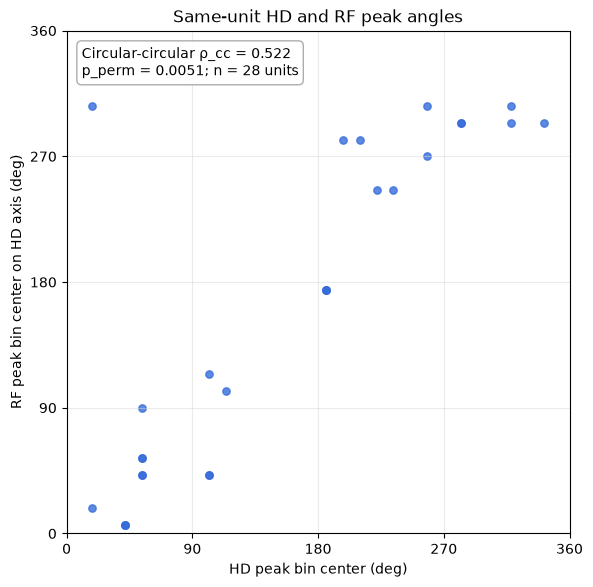

In [16]:
# Convert both peak indices to bin-center angles on the HD 0-360 degree axis.
HDangleBinCenters30 = (HDangleBinEdges30[:-1] + HDangleBinEdges30[1:]) / 2
HDmaxAngleCenterDeg = HDangleBinCenters30[HDmaxIndex]

RFxPositionCentersDeg = np.asarray(rf_data['xPositions'], dtype=float)
RFmaxAngleCenterOnHDAxisDeg = np.mod(
    -RFxPositionCentersDeg[RFmaxIndex],
    360.0,
)

# Align the two modalities explicitly by unit ID before statistics/plotting.
HDpeakAngleByUnit = dict(zip(HDselectedUnitIDs, HDmaxAngleCenterDeg))
RFactualSelectedUnitIDs = RFunitPool[np.isin(RFunitPool, targetList)]
RFpeakAngleByUnit = dict(zip(
    RFactualSelectedUnitIDs,
    RFmaxAngleCenterOnHDAxisDeg,
))
pairedUnitIDs = np.asarray([
    unitID for unitID in targetList
    if unitID in HDpeakAngleByUnit and unitID in RFpeakAngleByUnit
])
singleUnitHDanglesDeg = np.asarray([
    HDpeakAngleByUnit[unitID] for unitID in pairedUnitIDs
])
singleUnitRFanglesDeg = np.asarray([
    RFpeakAngleByUnit[unitID] for unitID in pairedUnitIDs
])
singleUnitHDanglesRad = np.deg2rad(singleUnitHDanglesDeg)
singleUnitRFanglesRad = np.deg2rad(singleUnitRFanglesDeg)

rho_circ, p_circ = circ_corrcc_permtest(
    singleUnitHDanglesRad,
    singleUnitRFanglesRad,
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED,
)
HDmeanResultantLength = np.abs(np.mean(np.exp(1j * singleUnitHDanglesRad)))
RFmeanResultantLength = np.abs(np.mean(np.exp(1j * singleUnitRFanglesRad)))

fig, ax = plt.subplots(figsize=(6, 6), facecolor='white')
ax.scatter(singleUnitHDanglesDeg, singleUnitRFanglesDeg, s=28, alpha=0.8)
ax.set(
    xlabel='HD peak bin center (deg)',
    ylabel='RF peak bin center on HD axis (deg)',
    title='Same-unit HD and RF peak angles',
    xlim=(0, 360),
    ylim=(0, 360),
    xticks=np.arange(0, 361, 90),
    yticks=np.arange(0, 361, 90),
)
if SHOW_STATS_ON_PLOT:
    ax.text(
        0.03,
        0.97,
        (
            f'Circular-circular ρ_cc = {rho_circ:.3f}\n'
            f'p_perm = {format_permutation_p(p_circ)}; '
            f'n = {len(pairedUnitIDs)} units'
        ),
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        color='black',
        bbox={
            'boxstyle': 'round,pad=0.35',
            'facecolor': 'white',
            'edgecolor': '0.65',
            'alpha': 0.92,
        },
    )
ax.set_aspect('equal', adjustable='box')
style_white_scatter_axes(fig, ax)
fig.tight_layout()
plt.show()

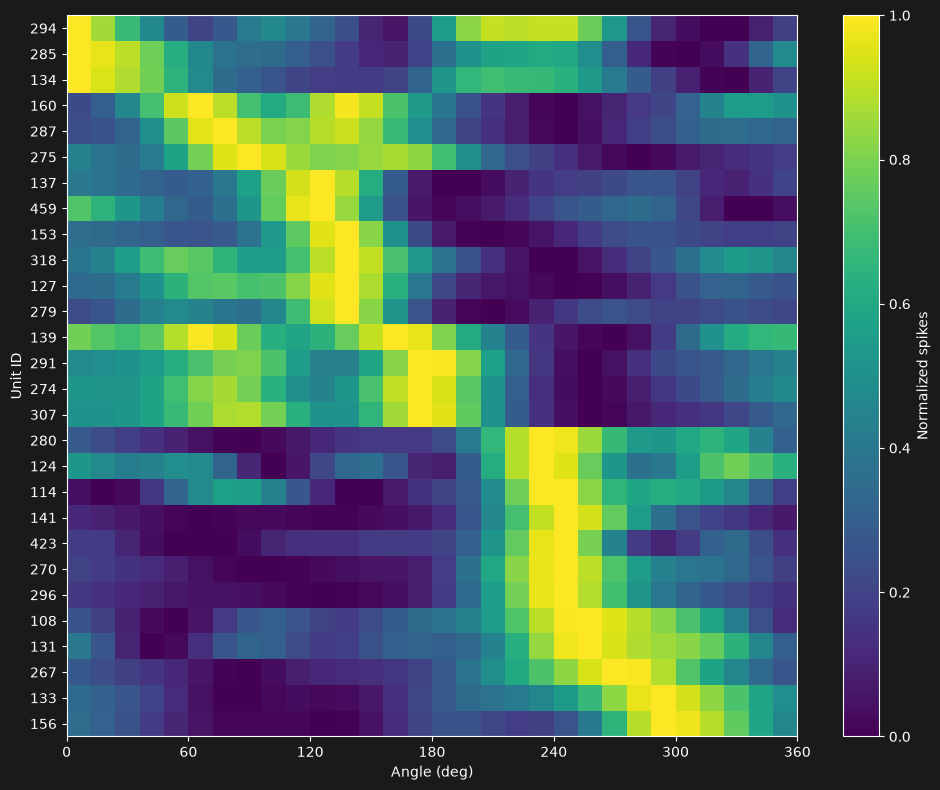

NameError: name 'unitsSpikeCounts_smooth_sorted' is not defined

In [21]:
plot_1d_rfmap(
    RFunitsSpikeCounts_smooth_sorted,
    label_list=RFtargetList_sorted,
    isHeatmap=True,
    xinDeg=True,
    isNormalize=True,
)

plot_1d_rfmap(
    unitsSpikeCounts_smooth_sorted,
    label_list=targetList_sorted,
    isLineplot=True,
    xinDeg=True,
    isNormalize=True,
)

In [ ]:
# Generate all unique unit-pair distances from the single-unit peak angles above.
from itertools import combinations
import pandas as pd

HDpeakAngleByUnit = dict(zip(HDselectedUnitIDs, HDmaxAngleCenterDeg))
RFactualSelectedUnitIDs = RFunitPool[np.isin(RFunitPool, targetList)]
RFpeakAngleByUnit = dict(zip(RFactualSelectedUnitIDs, RFmaxAngleCenterOnHDAxisDeg))

pairedUnitIDs = np.asarray([
    unitID for unitID in targetList
    if unitID in HDpeakAngleByUnit and unitID in RFpeakAngleByUnit
])

def signed_circular_difference_deg(angleA, angleB):
    return (angleB - angleA + 180.0) % 360.0 - 180.0

pairedRows = []
for unitA, unitB in combinations(pairedUnitIDs, 2):
    HDangleA = HDpeakAngleByUnit[unitA]
    HDangleB = HDpeakAngleByUnit[unitB]
    RFangleA = RFpeakAngleByUnit[unitA]
    RFangleB = RFpeakAngleByUnit[unitB]

    HDsignedDifference = signed_circular_difference_deg(HDangleA, HDangleB)
    RFsignedDifference = signed_circular_difference_deg(RFangleA, RFangleB)

    pairedRows.append({
        'unitA': int(unitA),
        'unitB': int(unitB),
        'HDangleA_deg': HDangleA,
        'HDangleB_deg': HDangleB,
        'RFangleA_deg': RFangleA,
        'RFangleB_deg': RFangleB,
        'HDsignedDifference_deg': HDsignedDifference,
        'RFsignedDifference_deg': RFsignedDifference,
        'HDpairDistance_deg': abs(HDsignedDifference),
        'RFpairDistance_deg': abs(RFsignedDifference),
    })

pairedData = pd.DataFrame(pairedRows)
expectedPairCount = len(pairedUnitIDs) * (len(pairedUnitIDs) - 1) // 2
assert len(pairedData) == expectedPairCount
pairedData

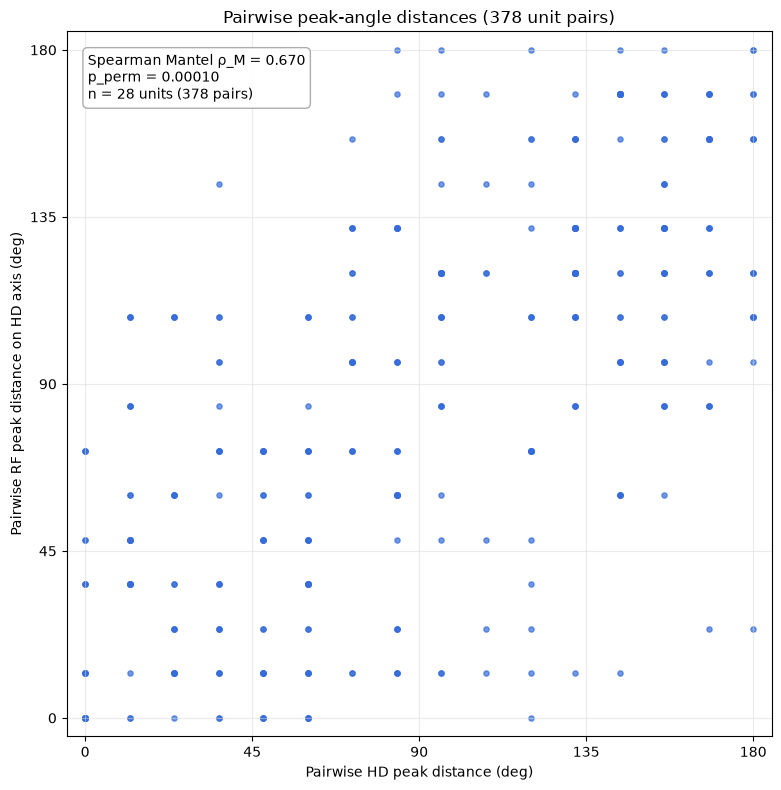

In [17]:
# Compare the HD and RF circular-distance structures without treating pairs as independent.
pairedHDanglesDeg = np.asarray([
    HDpeakAngleByUnit[unitID] for unitID in pairedUnitIDs
])
pairedRFanglesDeg = np.asarray([
    RFpeakAngleByUnit[unitID] for unitID in pairedUnitIDs
])
mantel_rho, mantel_p = spearman_mantel_permtest(
    pairedHDanglesDeg,
    pairedRFanglesDeg,
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED,
)

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')
ax.scatter(
    pairedData['HDpairDistance_deg'],
    pairedData['RFpairDistance_deg'],
    s=14,
    alpha=0.7,
)

if SHOW_PAIR_LABELS:
    for row in pairedData.itertuples(index=False):
        ax.annotate(
            f'({row.unitA},{row.unitB})',
            (row.HDpairDistance_deg, row.RFpairDistance_deg),
            xytext=(2, 2),
            textcoords='offset points',
            fontsize=4,
            alpha=0.7,
            color='black',
        )

ax.set(
    xlabel='Pairwise HD peak distance (deg)',
    ylabel='Pairwise RF peak distance on HD axis (deg)',
    title=f'Pairwise peak-angle distances ({len(pairedData)} unit pairs)',
    xlim=(-5, 185),
    ylim=(-5, 185),
    xticks=np.arange(0, 181, 45),
    yticks=np.arange(0, 181, 45),
)
if SHOW_STATS_ON_PLOT:
    ax.text(
        0.03,
        0.97,
        (
            f'Spearman Mantel ρ_M = {mantel_rho:.3f}\n'
            f'p_perm = {format_permutation_p(mantel_p)}\n'
            f'n = {len(pairedUnitIDs)} units ({len(pairedData)} pairs)'
        ),
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        color='black',
        bbox={
            'boxstyle': 'round,pad=0.35',
            'facecolor': 'white',
            'edgecolor': '0.65',
            'alpha': 0.92,
        },
    )
ax.set_aspect('equal', adjustable='box')
style_white_scatter_axes(fig, ax)
fig.tight_layout()
plt.show()

In [13]:
import numpy as np
from scipy.stats import circmean


def circ_corrcc(alpha, beta):
    """
    Jammalamadaka-SenGupta circular-circular correlation coefficient.
    alpha, beta: angles in radians
    """
    alpha = np.asarray(alpha, dtype=float).ravel()
    beta = np.asarray(beta, dtype=float).ravel()

    if alpha.shape != beta.shape:
        raise ValueError('alpha and beta must have the same shape')

    mask = np.isfinite(alpha) & np.isfinite(beta)
    alpha = alpha[mask]
    beta = beta[mask]
    if alpha.size < 3:
        raise ValueError('At least three finite angle pairs are required')
    if min(
        np.abs(np.mean(np.exp(1j * alpha))),
        np.abs(np.mean(np.exp(1j * beta))),
    ) <= np.finfo(float).eps:
        return np.nan

    alpha_bar = circmean(alpha, high=2 * np.pi, low=0)
    beta_bar = circmean(beta, high=2 * np.pi, low=0)

    sin_a = np.sin(alpha - alpha_bar)
    sin_b = np.sin(beta - beta_bar)

    denom = np.sqrt(np.sum(sin_a ** 2) * np.sum(sin_b ** 2))

    if np.isclose(denom, 0):
        return np.nan

    rho = np.sum(sin_a * sin_b) / denom
    return rho


def circ_corrcc_permtest(alpha, beta, n_perm=10000, seed=0):
    """
    Circular-circular correlation with permutation p-value.
    Two-sided p-value.
    """
    rng = np.random.default_rng(seed)
    if n_perm < 1:
        raise ValueError('n_perm must be positive')

    alpha = np.asarray(alpha, dtype=float).ravel()
    beta = np.asarray(beta, dtype=float).ravel()

    if alpha.shape != beta.shape:
        raise ValueError('alpha and beta must have the same shape')

    mask = np.isfinite(alpha) & np.isfinite(beta)
    alpha = alpha[mask]
    beta = beta[mask]
    if alpha.size < 3:
        raise ValueError('At least three finite angle pairs are required')

    rho_obs = circ_corrcc(alpha, beta)
    if not np.isfinite(rho_obs):
        return rho_obs, np.nan

    perm_rhos = np.empty(n_perm)

    for i in range(n_perm):
        beta_perm = rng.permutation(beta)
        perm_rhos[i] = circ_corrcc(alpha, beta_perm)

    # two-sided permutation p-value
    p_value = (np.sum(np.abs(perm_rhos) >= np.abs(rho_obs)) + 1) / (n_perm + 1)

    return rho_obs, p_value


# Use converted bin-center angles and align the two modalities by unit ID.
singleUnitHDanglesRad = np.deg2rad(np.asarray([
    HDpeakAngleByUnit[unitID] for unitID in pairedUnitIDs
]))
singleUnitRFanglesRad = np.deg2rad(np.asarray([
    RFpeakAngleByUnit[unitID] for unitID in pairedUnitIDs
]))

rho_circ, p_circ = circ_corrcc_permtest(
    singleUnitHDanglesRad,
    singleUnitRFanglesRad,
    n_perm=10000,
    seed=1,
)
HDmeanResultantLength = np.abs(np.mean(np.exp(1j * singleUnitHDanglesRad)))
RFmeanResultantLength = np.abs(np.mean(np.exp(1j * singleUnitRFanglesRad)))

print(f"Same-unit circular-circular rho = {rho_circ:.4f}")
print(f"Two-sided unit-label permutation p = {p_circ:.4g}")
print(f"Units = {singleUnitHDanglesRad.size}")
print(
    f"Mean resultant lengths: HD = {HDmeanResultantLength:.3f}, "
    f"RF = {RFmeanResultantLength:.3f}"
)

Same-unit circular-circular rho = 0.5220
Two-sided unit-label permutation p = 0.005099
Units = 28
Mean resultant lengths: HD = 0.119, RF = 0.284


In [14]:
from scipy.stats import rankdata


def circular_distance_matrix_deg(angles_deg):
    """Pairwise shortest-arc distances, in degrees (range 0-180)."""
    angles_deg = np.asarray(angles_deg, dtype=float).ravel()
    if not np.all(np.isfinite(angles_deg)):
        raise ValueError('All angles must be finite')

    delta = angles_deg[:, None] - angles_deg[None, :]
    return np.abs((delta + 180.0) % 360.0 - 180.0)


def spearman_mantel_permtest(HDangles_deg, RFangles_deg, n_perm=10000, seed=0):
    """Spearman Mantel test with simultaneous RF row/column permutations."""
    HDangles_deg = np.asarray(HDangles_deg, dtype=float).ravel()
    RFangles_deg = np.asarray(RFangles_deg, dtype=float).ravel()
    if n_perm < 1:
        raise ValueError('n_perm must be positive')
    if HDangles_deg.shape != RFangles_deg.shape:
        raise ValueError('HD and RF angles must have the same shape')
    if HDangles_deg.size < 3:
        raise ValueError('At least three paired units are required')

    HDdistanceMatrix = circular_distance_matrix_deg(HDangles_deg)
    RFdistanceMatrix = circular_distance_matrix_deg(RFangles_deg)
    upperTriangle = np.triu_indices(HDangles_deg.size, k=1)

    # Spearman correlation is Pearson correlation of ranks. Rank once because
    # every unit-label permutation only reorders the same pair distances.
    HDranks = rankdata(HDdistanceMatrix[upperTriangle])
    RFranks = rankdata(RFdistanceMatrix[upperTriangle])
    HDcenteredRanks = HDranks - HDranks.mean()
    RFcenteredRanks = RFranks - RFranks.mean()
    denominator = np.sqrt(
        np.sum(HDcenteredRanks ** 2) * np.sum(RFcenteredRanks ** 2)
    )
    if np.isclose(denominator, 0):
        return np.nan, np.nan

    rho_obs = np.sum(HDcenteredRanks * RFcenteredRanks) / denominator

    # Store pair ranks as a symmetric matrix so a permutation always moves
    # both endpoints of every pair together.
    RFrankMatrix = np.zeros_like(RFdistanceMatrix, dtype=float)
    RFrankMatrix[upperTriangle] = RFranks
    RFrankMatrix[(upperTriangle[1], upperTriangle[0])] = RFranks

    rng = np.random.default_rng(seed)
    perm_rhos = np.empty(n_perm)
    for i in range(n_perm):
        order = rng.permutation(HDangles_deg.size)
        RFpermutedRanks = RFrankMatrix[np.ix_(order, order)][upperTriangle]
        RFpermutedCentered = RFpermutedRanks - RFpermutedRanks.mean()
        perm_rhos[i] = (
            np.sum(HDcenteredRanks * RFpermutedCentered) / denominator
        )

    p_value = (
        np.sum(np.abs(perm_rhos) >= np.abs(rho_obs)) + 1
    ) / (n_perm + 1)
    return rho_obs, p_value


pairedHDanglesDeg = np.asarray([
    HDpeakAngleByUnit[unitID] for unitID in pairedUnitIDs
])
pairedRFanglesDeg = np.asarray([
    RFpeakAngleByUnit[unitID] for unitID in pairedUnitIDs
])

mantel_rho, mantel_p = spearman_mantel_permtest(
    pairedHDanglesDeg,
    pairedRFanglesDeg,
    n_perm=10000,
    seed=1,
)

print(f"Pairwise-distance Spearman Mantel rho = {mantel_rho:.4f}")
print(f"Two-sided unit-label permutation p = {mantel_p:.4g}")
print(f"Units = {len(pairedUnitIDs)}, unique pairs = {len(pairedData)}")

Pairwise-distance Spearman Mantel rho = 0.6703
Two-sided unit-label permutation p = 9.999e-05
Units = 28, unique pairs = 378


In [ ]:
unitsSpikeCounts_smooth_sorted

In [ ]:
x_idx = 2
values = unit_x[:, x_idx]  # one value per unit

unit_ids = np.arange(unit_x.shape[0])

img = values.reshape(1, -1)

plt.figure(figsize=(12, 1.5))
plt.imshow(img, aspect="equal", cmap="viridis")

plt.xticks(np.arange(len(unit_ids)), unit_ids)
plt.yticks([])

plt.xlabel("Unit ID")
plt.title(f"x = {x_idx}")
plt.colorbar(label="Summed value")

plt.tight_layout()
plt.show()